In [1]:
import os
import random
import itertools
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torchvision.utils as vutils
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
class CycleGANDatasetBM(Dataset):
    def __init__(self, root_dir):
        self.A_paths = []  # benign
        self.B_paths = []  # malignant

        valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

        for root, _, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(valid_ext):
                    full_path = os.path.join(root, f).lower()

                    if "/benign/" in full_path:
                        self.A_paths.append(os.path.join(root, f))
                    elif "/malignant/" in full_path:
                        self.B_paths.append(os.path.join(root, f))

        print(f"[INFO] Benign images: {len(self.A_paths)}")
        print(f"[INFO] Malignant images: {len(self.B_paths)}")

        if len(self.A_paths) == 0 or len(self.B_paths) == 0:
            raise RuntimeError("Benign or Malignant images not found.")

        self.transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return max(len(self.A_paths), len(self.B_paths))

    def __getitem__(self, idx):
        A_path = self.A_paths[idx % len(self.A_paths)]
        B_path = self.B_paths[random.randint(0, len(self.B_paths)-1)]

        A = Image.open(A_path).convert("RGB")
        B = Image.open(B_path).convert("RGB")

        return self.transform(A), self.transform(B)


In [4]:
dataset = CycleGANDatasetBM("/kaggle/input/breakhis/BreaKHis_v1")

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2
)


[INFO] Benign images: 2480
[INFO] Malignant images: 5429


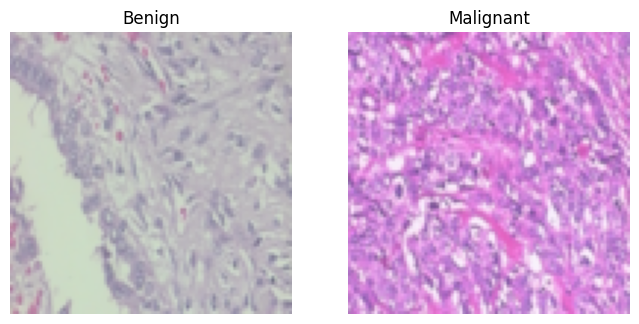

In [5]:
real_A, real_B = next(iter(dataloader))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Benign")
plt.imshow(real_A[0].permute(1,2,0)*0.5 + 0.5)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Malignant")
plt.imshow(real_B[0].permute(1,2,0)*0.5 + 0.5)
plt.axis("off")
plt.show()


In [6]:
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.block(x)


In [7]:
class Generator(nn.Module):
    def __init__(self, nc=3, ngf=64, n_blocks=6):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(nc, ngf, 7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(True)
        ]

        # Downsampling
        model += [
            nn.Conv2d(ngf, ngf*2, 3, 2, 1),
            nn.InstanceNorm2d(ngf*2),
            nn.ReLU(True),
            nn.Conv2d(ngf*2, ngf*4, 3, 2, 1),
            nn.InstanceNorm2d(ngf*4),
            nn.ReLU(True)
        ]

        # ResNet blocks
        for _ in range(n_blocks):
            model += [ResnetBlock(ngf*4)]

        # Upsampling
        model += [
            nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(ngf*2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(True)
        ]

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, nc, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


In [8]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1),
            nn.InstanceNorm2d(ndf*2),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),
            nn.InstanceNorm2d(ndf*4),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(ndf*4, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)


In [9]:
G_AB = Generator().to(device)  # Benign → Malignant
G_BA = Generator().to(device)  # Malignant → Benign
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)


In [10]:
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

lambda_cycle = 10
lambda_id = 5


In [11]:
optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=2e-4, betas=(0.5, 0.999)
)

optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5, 0.999))


In [12]:
num_epochs = 40   # 60 is possible but slower

for epoch in range(num_epochs):
    for real_A, real_B in dataloader:
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        valid = torch.ones_like(D_A(real_A))
        fake = torch.zeros_like(valid)

        # ------------------
        #  Train Generators
        # ------------------
        optimizer_G.zero_grad()

        # Identity loss
        loss_id = criterion_identity(G_AB(real_B), real_B) + \
                  criterion_identity(G_BA(real_A), real_A)

        # GAN loss
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)
        loss_GAN = criterion_GAN(D_B(fake_B), valid) + \
                   criterion_GAN(D_A(fake_A), valid)

        # Cycle loss
        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)
        loss_cycle = criterion_cycle(rec_A, real_A) + \
                     criterion_cycle(rec_B, real_B)

        loss_G = loss_GAN + lambda_cycle*loss_cycle + lambda_id*loss_id
        loss_G.backward()
        optimizer_G.step()

        # -----------------------
        #  Train Discriminator A
        # -----------------------
        optimizer_D_A.zero_grad()
        loss_D_A = criterion_GAN(D_A(real_A), valid) + \
                   criterion_GAN(D_A(fake_A.detach()), fake)
        loss_D_A.backward()
        optimizer_D_A.step()

        # -----------------------
        #  Train Discriminator B
        # -----------------------
        optimizer_D_B.zero_grad()
        loss_D_B = criterion_GAN(D_B(real_B), valid) + \
                   criterion_GAN(D_B(fake_B.detach()), fake)
        loss_D_B.backward()
        optimizer_D_B.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Loss_G: {loss_G.item():.4f}")


Epoch [1/40] | Loss_G: 3.3758
Epoch [2/40] | Loss_G: 3.7700
Epoch [3/40] | Loss_G: 4.4711
Epoch [4/40] | Loss_G: 9.7594
Epoch [5/40] | Loss_G: 4.3947
Epoch [6/40] | Loss_G: 3.0119
Epoch [7/40] | Loss_G: 4.0814
Epoch [8/40] | Loss_G: 4.2629
Epoch [9/40] | Loss_G: 3.2244
Epoch [10/40] | Loss_G: 3.5201
Epoch [11/40] | Loss_G: 3.2382
Epoch [12/40] | Loss_G: 5.0446
Epoch [13/40] | Loss_G: 3.4505
Epoch [14/40] | Loss_G: 4.7202
Epoch [15/40] | Loss_G: 4.2823
Epoch [16/40] | Loss_G: 3.3672
Epoch [17/40] | Loss_G: 2.8184


KeyboardInterrupt: 

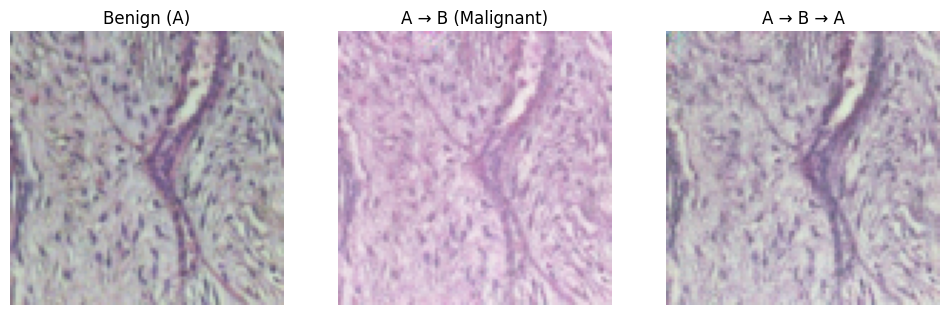

In [15]:
G_AB.eval()
G_BA.eval()

with torch.no_grad():
    fake_B = G_AB(real_A)
    rec_A = G_BA(fake_B)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Benign (A)")
plt.imshow(
    (real_A[0].detach().cpu().permute(1,2,0) * 0.5 + 0.5).numpy()
)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("A → B (Malignant)")
plt.imshow(
    (fake_B[0].detach().cpu().permute(1,2,0) * 0.5 + 0.5).numpy()
)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("A → B → A")
plt.imshow(
    (rec_A[0].detach().cpu().permute(1,2,0) * 0.5 + 0.5).numpy()
)
plt.axis("off")

plt.show()


In [16]:
torch.save(G_AB.state_dict(), "cyclegan_G_AB.pth")
torch.save(G_BA.state_dict(), "cyclegan_G_BA.pth")
torch.save(D_A.state_dict(), "cyclegan_D_A.pth")
torch.save(D_B.state_dict(), "cyclegan_D_B.pth")


In [30]:
def collect_many_cyclegan_images(G_AB, G_BA, dataloader, device, n_samples=200):
    G_AB.eval()
    G_BA.eval()

    real_B_list = []
    fake_B_list = []

    collected = 0

    with torch.no_grad():
        for A, B in dataloader:
            A = A.to(device)
            B = B.to(device)

            fake_B = G_AB(A)

            real_B_list.append(B.cpu())
            fake_B_list.append(fake_B.cpu())

            collected += 1
            if collected >= n_samples:
                break

    real_B = torch.cat(real_B_list, dim=0)
    fake_B = torch.cat(fake_B_list, dim=0)

    return real_B, fake_B


In [31]:
real_B, fake_B = collect_many_cyclegan_images(
    G_AB, G_BA, dataloader, device, n_samples=200
)

print(real_B.shape, fake_B.shape)


torch.Size([200, 3, 96, 96]) torch.Size([200, 3, 96, 96])


In [33]:
from torchvision.models import inception_v3
import torch.nn.functional as F
import numpy as np
from scipy.linalg import sqrtm


In [34]:
inception = inception_v3(pretrained=True).to(device)
inception.fc = nn.Identity()
inception.eval()


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [35]:
def inception_features(images):
    feats = []
    with torch.no_grad():
        for i in range(0, len(images), 32):
            batch = F.interpolate(images[i:i+32].to(device), size=299)
            feats.append(inception(batch).cpu())
    return torch.cat(feats).numpy()


In [36]:
real_feats = inception_features(real_B)
fake_feats = inception_features(fake_B)


In [37]:
def compute_fid(real_feats, fake_feats):
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    cov_r = np.cov(real_feats, rowvar=False)
    cov_f = np.cov(fake_feats, rowvar=False)

    covmean = sqrtm(cov_r @ cov_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return np.sum((mu_r - mu_f)**2) + np.trace(cov_r + cov_f - 2*covmean)


In [38]:
print("real_feats shape:", real_feats.shape)
print("fake_feats shape:", fake_feats.shape)


real_feats shape: (200, 2048)
fake_feats shape: (200, 2048)


In [39]:
fid = compute_fid(real_feats, fake_feats)
print("FID (A→B):", fid)


FID (A→B): 66.98524335235864


In [40]:
from skimage.metrics import structural_similarity as ssim


In [44]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def compute_cycle_ssim(real_A, rec_A, n=100):
    """
    real_A, rec_A: tensors of shape [N, 3, H, W]
    Can be on GPU or CPU.
    """
    scores = []

    # Move once to CPU (efficient and safe)
    real_A = real_A.detach().cpu()
    rec_A = rec_A.detach().cpu()

    n = min(n, real_A.size(0))

    for i in range(n):
        a = real_A[i].permute(1,2,0).numpy()
        r = rec_A[i].permute(1,2,0).numpy()

        score = ssim(
            a, r,
            channel_axis=2,
            data_range=2   # because images are in [-1, 1]
        )
        scores.append(score)

    return float(np.mean(scores))


In [45]:
cycle_ssim = compute_cycle_ssim(real_A, rec_A, n=100)
print("Cycle SSIM:", cycle_ssim)


Cycle SSIM: 0.8189577460289001


In [46]:
def compute_mmd(x, y, sigma=1.0):
    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    Kxx = torch.exp(-(rx.t() + rx - 2*xx) / (2*sigma))
    Kyy = torch.exp(-(ry.t() + ry - 2*yy) / (2*sigma))
    Kxy = torch.exp(-(rx.t() + ry - 2*xy) / (2*sigma))

    return Kxx.mean() + Kyy.mean() - 2*Kxy.mean()


In [47]:
mmd = compute_mmd(
    torch.tensor(real_feats[:200]),
    torch.tensor(fake_feats[:200])
)
print("MMD:", mmd.item())


MMD: 0.010449999943375587


In [48]:
print("FID (A→B):", fid)
print("Cycle SSIM:", cycle_ssim)
print("MMD:", mmd.item())

FID (A→B): 66.98524335235864
Cycle SSIM: 0.8189577460289001
MMD: 0.010449999943375587
